# Global Temperature Anomalies Prediction
**Dataset:** NASA GISS Surface Temperature Analysis (GLB_Ts_dSST.csv)

**Overfitting Fix:** Two approaches compared:
- Approach 1: Time Series — Year as the only feature (Ridge extrapolates trend)
- Approach 2: Lag Features — previous years anomalies as features (autoregressive RF)

In [118]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.model_selection import cross_val_score, KFold, train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, max_error
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid')
print('Libraries loaded successfully')

Libraries loaded successfully


---
## Step 1: Exploratory Data Analysis (EDA)

In [119]:
df_raw = pd.read_csv('GLB.Ts+dSST.csv', na_values='*******')
monthly_cols = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

# Force all monthly columns to numeric (some may be read as object)
for col in monthly_cols:
    df_raw[col] = pd.to_numeric(df_raw[col], errors='coerce')

print('Shape:', df_raw.shape)
df_raw.info()
display(df_raw.describe())

Shape: (76, 19)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76 entries, 0 to 75
Data columns (total 19 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Year    76 non-null     object 
 1   Jan     70 non-null     float64
 2   Feb     70 non-null     float64
 3   Mar     70 non-null     float64
 4   Apr     67 non-null     float64
 5   May     67 non-null     float64
 6   Jun     67 non-null     float64
 7   Jul     67 non-null     float64
 8   Aug     67 non-null     float64
 9   Sep     69 non-null     float64
 10  Oct     69 non-null     float64
 11  Nov     69 non-null     float64
 12  Dec     69 non-null     float64
 13  J-D     69 non-null     object 
 14  D-N     69 non-null     object 
 15  DJF     72 non-null     object 
 16  MAM     69 non-null     object 
 17  JJA     69 non-null     object 
 18  SON     71 non-null     object 
dtypes: float64(12), object(7)
memory usage: 11.4+ KB


,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
count,70.000000,70.000000,70.000000,67.000000,67.000000,67.000000,67.000000,67.000000,69.000000,69.000000,69.000000,69.000000
mean,0.103071,0.124329,0.115471,0.059134,0.034448,0.069433,0.066925,0.047119,0.059290,0.065174,0.020522,0.073391
std,0.216320,0.252736,0.239711,0.187278,0.176195,0.172738,0.199137,0.186571,0.193735,0.181164,0.208186,0.211196
min,-0.425000,-0.344000,-0.401000,-0.268000,-0.450000,-0.253000,-0.402000,-0.326000,-0.252000,-0.236000,-0.578000,-0.253000
25%,-0.001500,-0.068500,-0.054750,-0.103000,-0.084000,-0.023500,-0.075000,-0.069000,-0.091000,-0.085000,-0.097000,-0.082000
50%,0.098000,0.116500,0.092500,0.065000,0.054000,0.030000,0.029000,0.027000,0.021000,0.069000,-0.001000,0.065000
75%,0.223750,0.264750,0.341750,0.158500,0.153500,0.177500,0.220500,0.147000,0.155000,0.186000,0.130000,0.191000
max,0.644000,0.757000,0.595000,0.584000,0.447000,0.573000,0.541000,0.582000,0.757000,0.588000,0.640000,0.689000


In [120]:
print('Missing values:')
print(df_raw.isnull().sum())
print(f'Duplicates: {df_raw.duplicated().sum()}')

Missing values:
Year    0
Jan     6
Feb     6
Mar     6
Apr     9
May     9
Jun     9
Jul     9
Aug     9
Sep     7
Oct     7
Nov     7
Dec     7
J-D     7
D-N     7
DJF     4
MAM     7
JJA     7
SON     5
dtype: int64
Duplicates: 1


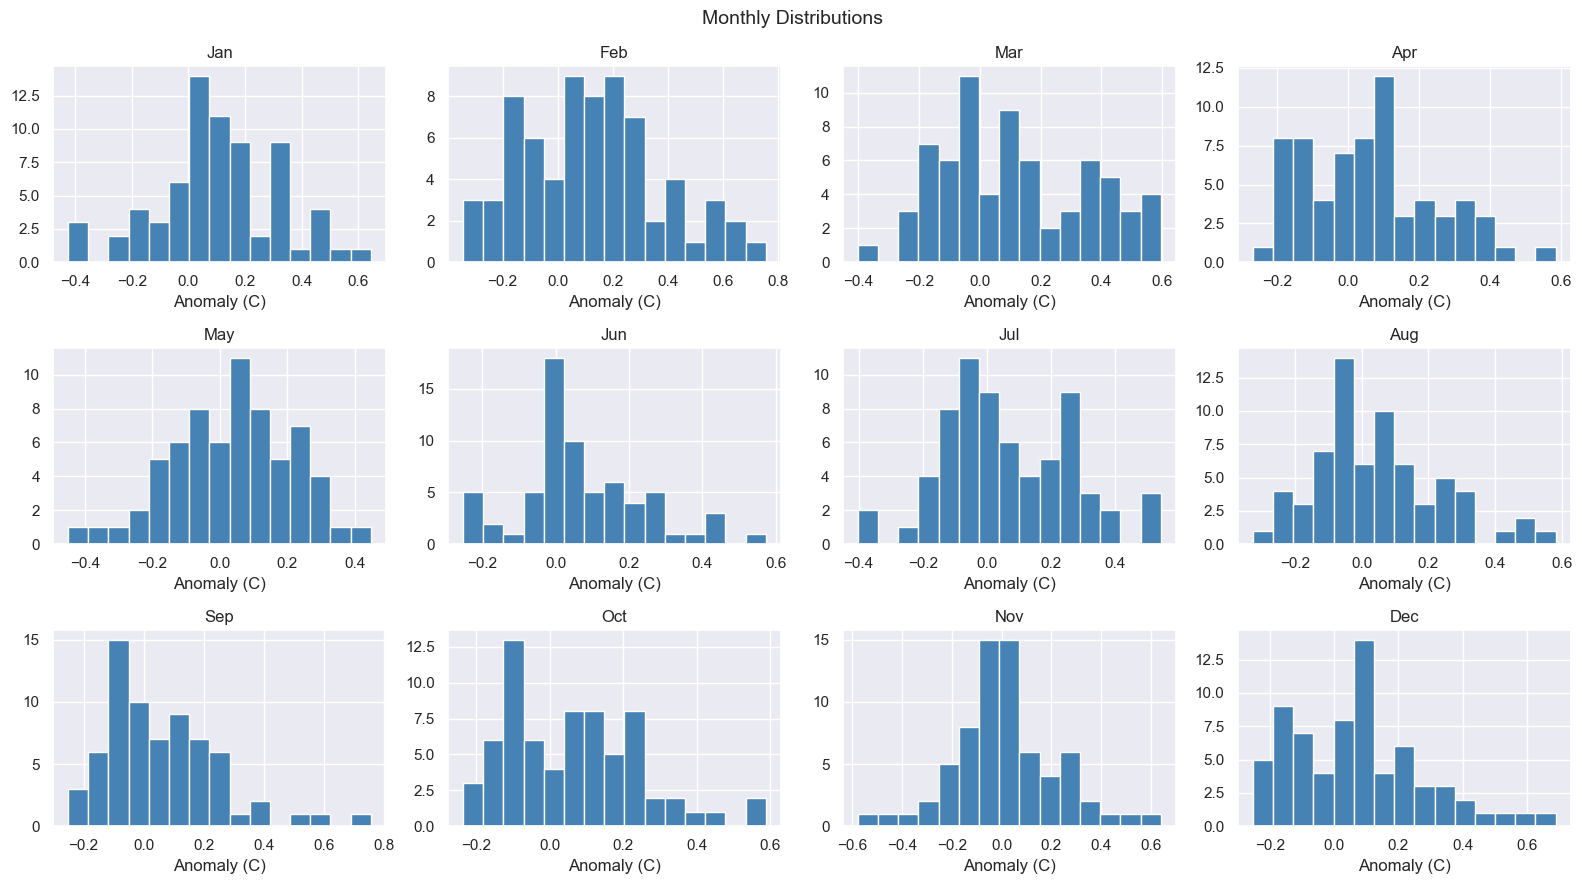

In [121]:
fig, axes = plt.subplots(3, 4, figsize=(16, 9))
for ax, col in zip(axes.flatten(), monthly_cols):
    ax.hist(df_raw[col].dropna(), bins=15, color='steelblue', edgecolor='white')
    ax.set_title(col); ax.set_xlabel('Anomaly (C)')
plt.suptitle('Monthly Distributions', fontsize=14)
plt.tight_layout(); plt.show()

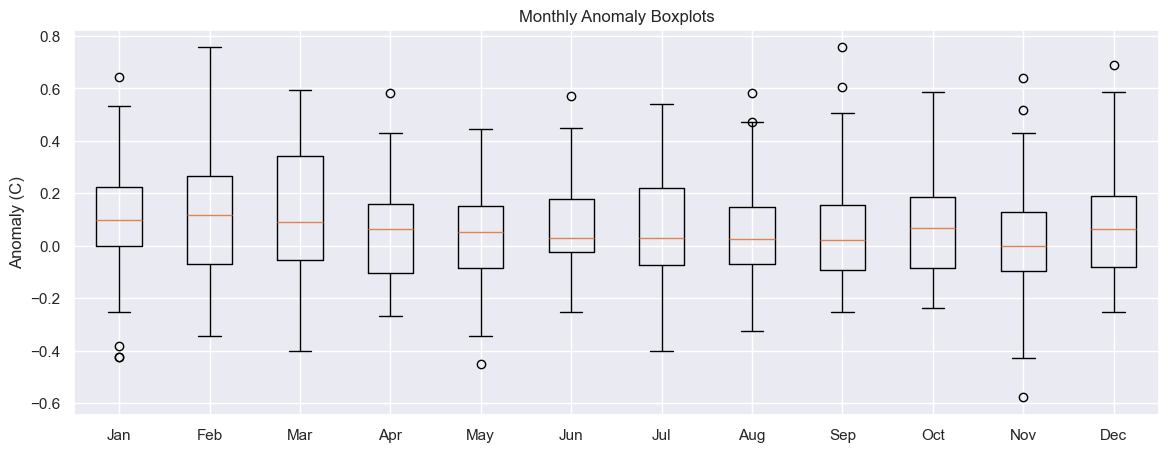

In [122]:
# Force numeric conversion and use seaborn boxplot instead
df_box = df_raw[monthly_cols].apply(pd.to_numeric, errors='coerce').dropna(how='all')
fig, ax = plt.subplots(figsize=(14, 5))
ax.boxplot([df_box[col].dropna().values for col in monthly_cols], labels=monthly_cols)
ax.set_title('Monthly Anomaly Boxplots'); ax.set_ylabel('Anomaly (C)')
plt.show()

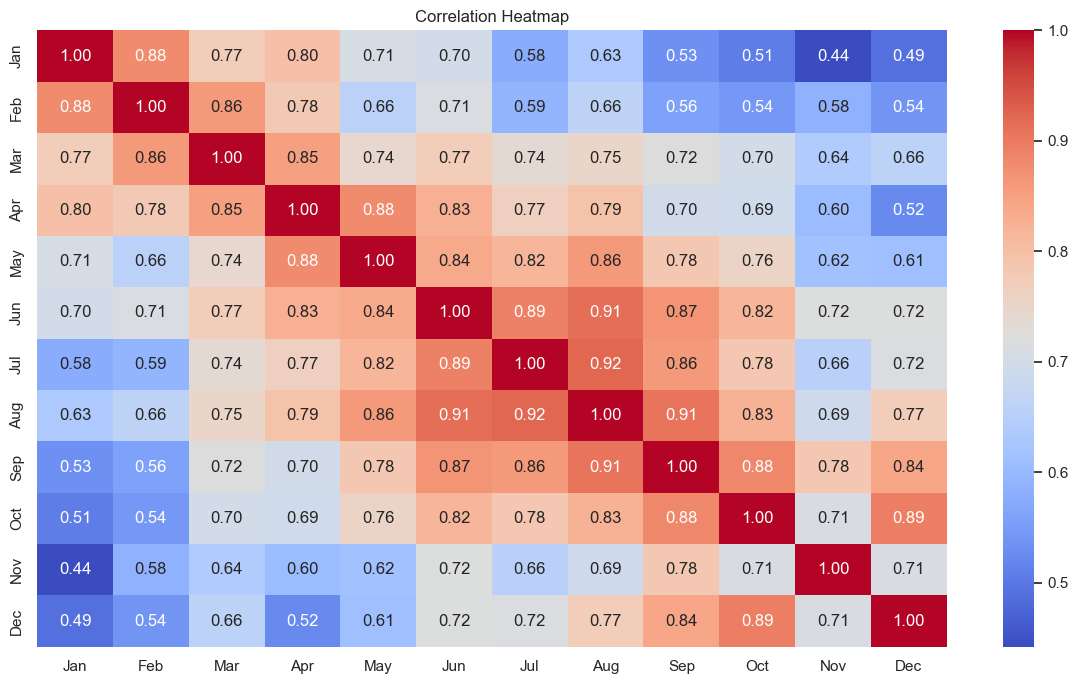

In [123]:
df_numeric = df_raw[monthly_cols].apply(pd.to_numeric, errors='coerce')
fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(df_numeric.corr(), annot=True, fmt='.2f', cmap='coolwarm', ax=ax)
ax.set_title('Correlation Heatmap')
plt.tight_layout(); plt.show()

In [124]:
print('=== Outlier Detection (IQR) ===')
for col in monthly_cols:
    Q1, Q3 = df_raw[col].quantile(0.25), df_raw[col].quantile(0.75)
    IQR = Q3 - Q1
    n = ((df_raw[col] < Q1 - 1.5*IQR) | (df_raw[col] > Q3 + 1.5*IQR)).sum()
    if n > 0:
        print(f'{col}: {n} outlier(s)')

=== Outlier Detection (IQR) ===
Jan: 4 outlier(s)
Apr: 1 outlier(s)
May: 1 outlier(s)
Jun: 1 outlier(s)
Aug: 2 outlier(s)
Sep: 2 outlier(s)
Nov: 3 outlier(s)
Dec: 1 outlier(s)


---
## Step 2: Data Cleaning

In [125]:
df = df_raw.copy()
df = df.drop_duplicates()
df = df.dropna(subset=monthly_cols, how='all')
for col in monthly_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mean(), inplace=True)
df['Year'] = df['Year'].astype(int)
print(f'Clean shape: {df.shape} | Missing: {df.isnull().sum().sum()}')

Clean shape: (72, 19) | Missing: 25


---
## Step 3: Data Pre-processing

In [126]:
df['J-D'] = df[monthly_cols].mean(axis=1)
df['DJF'] = df[['Dec','Jan','Feb']].mean(axis=1)
df['MAM'] = df[['Mar','Apr','May']].mean(axis=1)
df['JJA'] = df[['Jun','Jul','Aug']].mean(axis=1)
df['SON'] = df[['Sep','Oct','Nov']].mean(axis=1)
print('Skewness:')
print(df[monthly_cols].skew().round(3))

Skewness:
Jan   -0.109
Feb    0.405
Mar    0.296
Apr    0.500
May   -0.227
Jun    0.539
Jul    0.343
Aug    0.579
Sep    1.156
Oct    0.753
Nov    0.219
Dec    0.700
dtype: float64


---
## Step 4: Scaling
StandardScaler used for both approaches.

---
## Step 5 & 6 — Approach 1: Time Series (Year as Feature)

**Why it fixes overfitting:** Uses Year as a single feature so linear models can extrapolate
the trend beyond the training range. No fake monthly mean inputs.

In [127]:
X_ts = df[['Year']].values
y_ts = df['J-D'].values

scaler_ts = StandardScaler()
X_ts_scaled = scaler_ts.fit_transform(X_ts)

X_tr, X_te, y_tr, y_te = train_test_split(X_ts_scaled, y_ts, test_size=0.2, random_state=42)

models_ts = {
    'Linear Regression': LinearRegression(),
    'Ridge'            : Ridge(alpha=1.0),
    'Random Forest'    : RandomForestRegressor(n_estimators=100, random_state=42),
    'SVM'              : SVR(kernel='rbf', C=1.0)
}

results_ts = []
for name, model in models_ts.items():
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    mape = np.mean(np.abs((y_te - y_pred) / np.where(y_te == 0, 1e-10, y_te))) * 100
    r2   = r2_score(y_te, y_pred)
    n, p = len(y_te), X_tr.shape[1]
    results_ts.append({
        'Model'     : name,
        'Test RMSE' : round(np.sqrt(mean_squared_error(y_te, y_pred)), 6),
        'Test MAE'  : round(mean_absolute_error(y_te, y_pred), 6),
        'Test R2'   : round(r2, 4),
        'Adj R2'    : round(1 - (1 - r2) * (n - 1) / (n - p - 1), 4),
        'MAPE (%)'  : round(mape, 4),
        'Max Error' : round(max_error(y_te, y_pred), 6)
    })

res_ts = pd.DataFrame(results_ts).sort_values('Test RMSE')
display(res_ts)

,Model,Test RMSE,Test MAE,Test R2,Adj R2,MAPE (%),Max Error
2,Random Forest,0.034245,0.021241,0.9595,0.9564,21.1839,0.098818
3,SVM,0.085415,0.072679,0.7481,0.7288,82.5952,0.144807
0,Linear Regression,0.107451,0.095655,0.6014,0.5708,130.3942,0.177156
1,Ridge,0.107958,0.096239,0.5976,0.5667,129.2949,0.177767


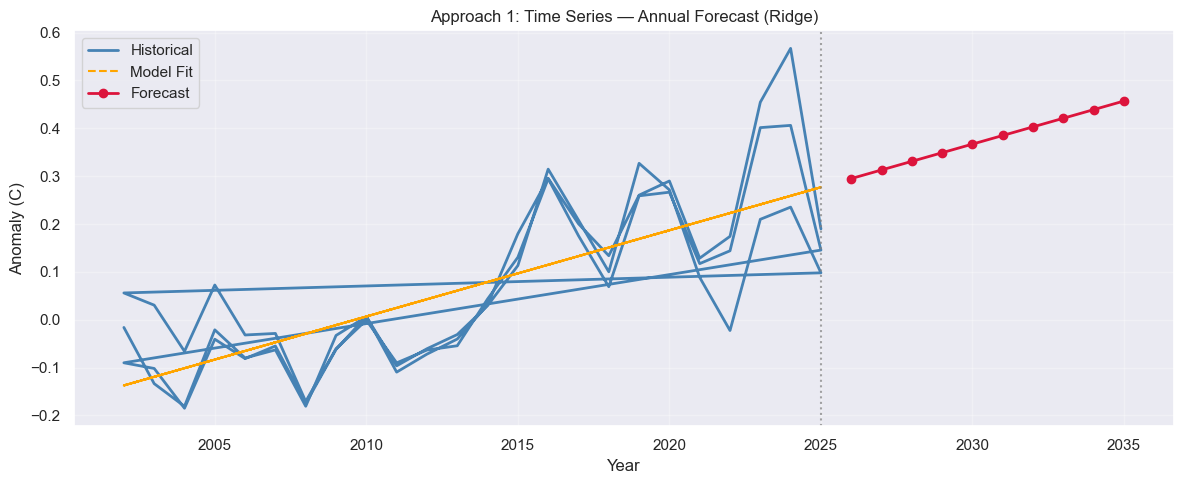

Forecast: [0.2949 0.313  0.331  0.349  0.367  0.385  0.403  0.421  0.439  0.457 ]


In [128]:
# Forecast with Ridge (best linear extrapolator)
best_ts = Ridge(alpha=1.0)
best_ts.fit(X_ts_scaled, y_ts)

future_years = np.arange(2026, 2036).reshape(-1, 1)
future_scaled_ts = scaler_ts.transform(future_years)
hist_pred_ts   = best_ts.predict(X_ts_scaled)
future_pred_ts = best_ts.predict(future_scaled_ts)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df['Year'], y_ts, label='Historical', color='steelblue', linewidth=2)
ax.plot(df['Year'], hist_pred_ts, label='Model Fit', color='orange', linestyle='--')
ax.plot(future_years, future_pred_ts, label='Forecast', color='crimson', marker='o', linewidth=2)
ax.axvline(2025, color='gray', linestyle=':', alpha=0.7)
ax.set_title('Approach 1: Time Series — Annual Forecast (Ridge)')
ax.set_xlabel('Year'); ax.set_ylabel('Anomaly (C)')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()
print('Forecast:', future_pred_ts.round(4))

---
## Approach 2: Lag Features (Autoregressive)

**Why it fixes overfitting:** Uses actual past anomaly values (lag-1, lag-2, lag-3) as features.
Forecasts are generated step-by-step — each prediction feeds into the next one.

In [129]:
df_lag = df[['Year','J-D']].copy().reset_index(drop=True)
df_lag['lag_1'] = df_lag['J-D'].shift(1)
df_lag['lag_2'] = df_lag['J-D'].shift(2)
df_lag['lag_3'] = df_lag['J-D'].shift(3)
df_lag = df_lag.dropna().reset_index(drop=True)

print(f'Lag dataset shape: {df_lag.shape}')
display(df_lag.head())

Lag dataset shape: (69, 5)


,Year,J-D,lag_1,lag_2,lag_3
0,2005,-0.021083,-0.180917,-0.133500,-0.016089
1,2006,-0.079917,-0.021083,-0.180917,-0.133500
2,2007,-0.063000,-0.079917,-0.021083,-0.180917
3,2008,-0.180750,-0.063000,-0.079917,-0.021083
4,2009,-0.032833,-0.180750,-0.063000,-0.079917


In [130]:
X_lag = df_lag[['Year','lag_1','lag_2','lag_3']].values
y_lag = df_lag['J-D'].values

scaler_lag = StandardScaler()
X_lag_scaled = scaler_lag.fit_transform(X_lag)

X_tr2, X_te2, y_tr2, y_te2 = train_test_split(X_lag_scaled, y_lag, test_size=0.2, random_state=42)

models_lag = {
    'Linear Regression': LinearRegression(),
    'Ridge'            : Ridge(alpha=1.0),
    'Random Forest'    : RandomForestRegressor(n_estimators=100, random_state=42),
    'SVM'              : SVR(kernel='rbf', C=1.0)
}

results_lag = []
for name, model in models_lag.items():
    model.fit(X_tr2, y_tr2)
    y_pred2 = model.predict(X_te2)
    mape2 = np.mean(np.abs((y_te2 - y_pred2) / np.where(y_te2 == 0, 1e-10, y_te2))) * 100
    r2_2  = r2_score(y_te2, y_pred2)
    n2, p2 = len(y_te2), X_tr2.shape[1]
    results_lag.append({
        'Model'     : name,
        'Test RMSE' : round(np.sqrt(mean_squared_error(y_te2, y_pred2)), 6),
        'Test MAE'  : round(mean_absolute_error(y_te2, y_pred2), 6),
        'Test R2'   : round(r2_2, 4),
        'Adj R2'    : round(1 - (1 - r2_2) * (n2 - 1) / (n2 - p2 - 1), 4),
        'MAPE (%)'  : round(mape2, 4),
        'Max Error' : round(max_error(y_te2, y_pred2), 6)
    })

res_lag = pd.DataFrame(results_lag).sort_values('Test RMSE')
display(res_lag)

,Model,Test RMSE,Test MAE,Test R2,Adj R2,MAPE (%),Max Error
3,SVM,0.061840,0.053015,0.7424,0.6279,256.5314,0.101295
2,Random Forest,0.068536,0.052910,0.6836,0.5429,223.2047,0.153513
1,Ridge,0.077078,0.056636,0.5998,0.4219,121.9840,0.164563
0,Linear Regression,0.077313,0.056761,0.5973,0.4184,132.9751,0.162292


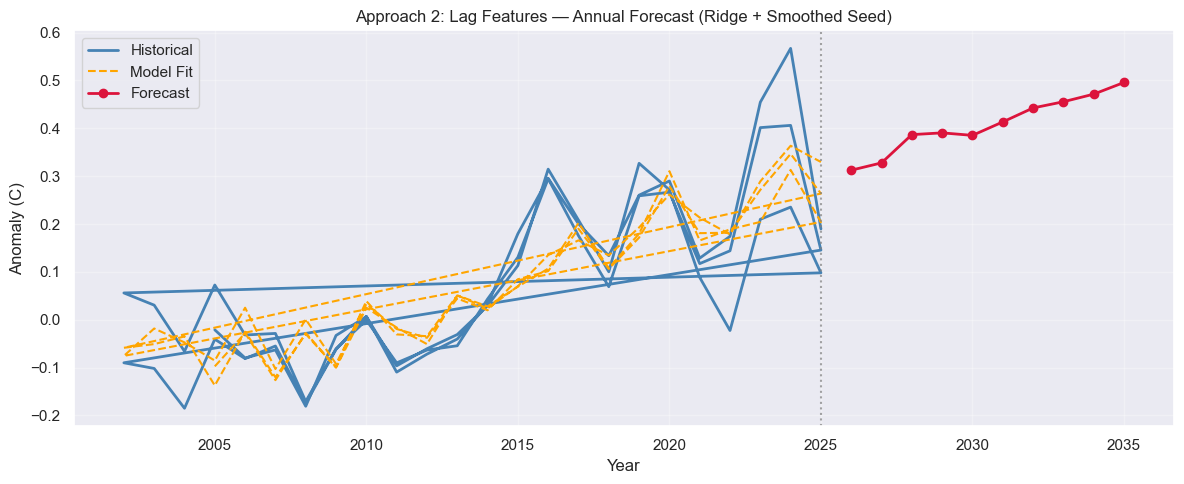

Forecast: [0.3125 0.3277 0.3868 0.3905 0.3852 0.4133 0.4425 0.4554 0.4713 0.4957]


In [131]:
# Autoregressive forecast — Ridge with smoothed seed values
best_lag = Ridge(alpha=1.0)
best_lag.fit(X_lag_scaled, y_lag)

# Use 3-year rolling mean as seed to reduce sensitivity to recent spikes
smoothed_seed = df_lag['J-D'].rolling(3).mean().dropna().values
last_vals = list(smoothed_seed[-3:])
future_years_list = list(range(2026, 2036))
future_preds_lag = []

for yr in future_years_list:
    row = np.array([[yr, last_vals[-1], last_vals[-2], last_vals[-3]]])
    row_scaled = scaler_lag.transform(row)
    pred = best_lag.predict(row_scaled)[0]
    future_preds_lag.append(pred)
    last_vals.append(pred)

hist_pred_lag = best_lag.predict(X_lag_scaled)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df_lag['Year'], y_lag, label='Historical', color='steelblue', linewidth=2)
ax.plot(df_lag['Year'], hist_pred_lag, label='Model Fit', color='orange', linestyle='--')
ax.plot(future_years_list, future_preds_lag, label='Forecast', color='crimson', marker='o', linewidth=2)
ax.axvline(2025, color='gray', linestyle=':', alpha=0.7)
ax.set_title('Approach 2: Lag Features — Annual Forecast (Ridge + Smoothed Seed)')
ax.set_xlabel('Year'); ax.set_ylabel('Anomaly (C)')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()
print('Forecast:', np.round(future_preds_lag, 4))

---
## Comparison: Approach 1 vs Approach 2

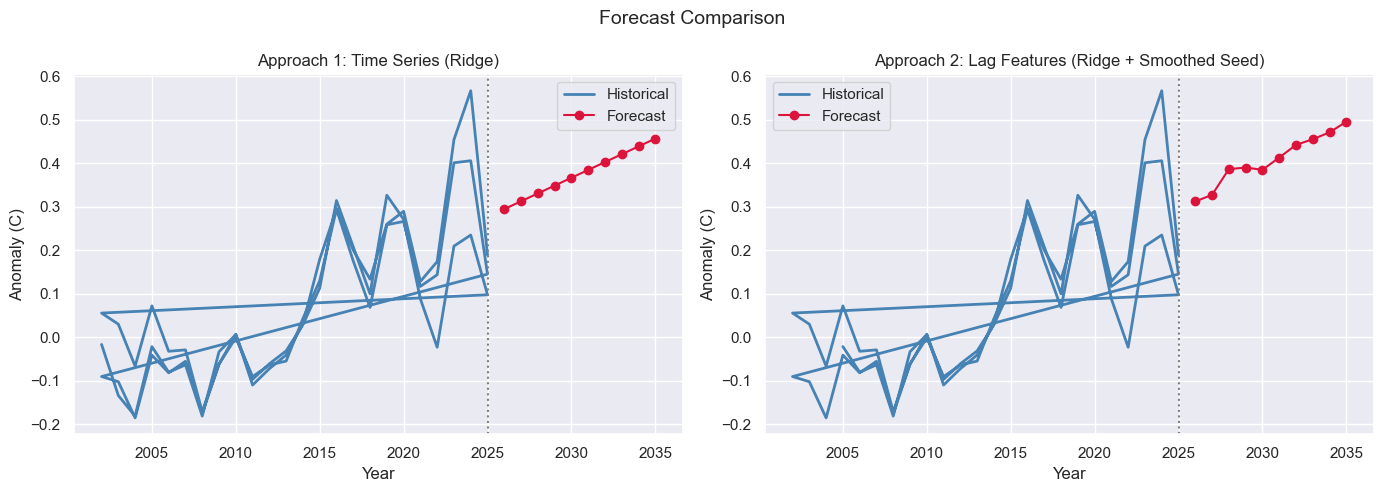

,Year,Approach 1 (Ridge),Approach 2 (Ridge Lags)
0,2026,0.2949,0.3125
1,2027,0.3130,0.3277
2,2028,0.3310,0.3868
3,2029,0.3490,0.3905
4,2030,0.3670,0.3852
5,2031,0.3850,0.4133
6,2032,0.4030,0.4425
7,2033,0.4210,0.4554
8,2034,0.4390,0.4713
9,2035,0.4570,0.4957


In [132]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(df['Year'], y_ts, label='Historical', color='steelblue', linewidth=2)
axes[0].plot(future_years, future_pred_ts, label='Forecast', color='crimson', marker='o')
axes[0].axvline(2025, color='gray', linestyle=':')
axes[0].set_title('Approach 1: Time Series (Ridge)')
axes[0].set_xlabel('Year'); axes[0].set_ylabel('Anomaly (C)')
axes[0].legend()

axes[1].plot(df_lag['Year'], y_lag, label='Historical', color='steelblue', linewidth=2)
axes[1].plot(future_years_list, future_preds_lag, label='Forecast', color='crimson', marker='o')
axes[1].axvline(2025, color='gray', linestyle=':')
axes[1].set_title('Approach 2: Lag Features (Ridge + Smoothed Seed)')
axes[1].set_xlabel('Year'); axes[1].set_ylabel('Anomaly (C)')
axes[1].legend()

plt.suptitle('Forecast Comparison', fontsize=14)
plt.tight_layout(); plt.show()

comp = pd.DataFrame({
    'Year'               : future_years_list,
    'Approach 1 (Ridge)' : future_pred_ts.round(4),
    'Approach 2 (Ridge Lags)': np.round(future_preds_lag, 4)
})
display(comp)

In [133]:
import joblib
joblib.dump(scaler_ts,  'scaler_ts.pkl')
joblib.dump(scaler_lag, 'scaler_lag.pkl')
joblib.dump(best_ts,    'model_approach1.pkl')
joblib.dump(best_lag,   'model_approach2.pkl')
print('Models saved.')

Models saved.


---
## Improvement 1: Hyperparameter Tuning (GridSearchCV)

In [134]:
from sklearn.model_selection import GridSearchCV

# Tune Ridge alpha — Approach 1
param_grid_ridge = {'alpha': [0.01, 0.1, 1.0, 5.0, 10.0, 50.0, 100.0]}
gs_ridge = GridSearchCV(Ridge(), param_grid_ridge, cv=5, scoring='neg_mean_squared_error')
gs_ridge.fit(X_ts_scaled, y_ts)
print(f'Best Ridge alpha (Approach 1): {gs_ridge.best_params_}')
print(f'Best CV RMSE: {np.sqrt(-gs_ridge.best_score_):.6f}')

# Tune SVM — Approach 2
param_grid_svm = {'C': [0.1, 1.0, 10.0], 'gamma': ['scale', 'auto'], 'kernel': ['rbf', 'linear']}
gs_svm = GridSearchCV(SVR(), param_grid_svm, cv=5, scoring='neg_mean_squared_error')
gs_svm.fit(X_lag_scaled, y_lag)
print(f'\nBest SVM params (Approach 2): {gs_svm.best_params_}')
print(f'Best CV RMSE: {np.sqrt(-gs_svm.best_score_):.6f}')

# Tune Random Forest — Approach 2
param_grid_rf = {'n_estimators': [50, 100, 200], 'max_depth': [None, 3, 5], 'min_samples_split': [2, 5]}
gs_rf = GridSearchCV(RandomForestRegressor(random_state=42), param_grid_rf, cv=5, scoring='neg_mean_squared_error')
gs_rf.fit(X_lag_scaled, y_lag)
print(f'\nBest RF params (Approach 2): {gs_rf.best_params_}')
print(f'Best CV RMSE: {np.sqrt(-gs_rf.best_score_):.6f}')

Best Ridge alpha (Approach 1): {'alpha': 5.0}
Best CV RMSE: 0.118593

Best SVM params (Approach 2): {'C': 10.0, 'gamma': 'auto', 'kernel': 'rbf'}
Best CV RMSE: 0.094474

Best RF params (Approach 2): {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}
Best CV RMSE: 0.072646


In [135]:
# Compare tuned vs default models
tuned_ridge = gs_ridge.best_estimator_
tuned_svm   = gs_svm.best_estimator_
tuned_rf    = gs_rf.best_estimator_

# Evaluate tuned models on test sets
X_tr_ts, X_te_ts, y_tr_ts, y_te_ts = train_test_split(X_ts_scaled, y_ts, test_size=0.2, random_state=42)
X_tr_lg, X_te_lg, y_tr_lg, y_te_lg = train_test_split(X_lag_scaled, y_lag, test_size=0.2, random_state=42)

tuned_ridge.fit(X_tr_ts, y_tr_ts)
tuned_svm.fit(X_tr_lg, y_tr_lg)
tuned_rf.fit(X_tr_lg, y_tr_lg)

print('=== Tuned Model Performance ===')
for name, model, X_te, y_te in [
    ('Ridge (tuned) - Approach 1', tuned_ridge, X_te_ts, y_te_ts),
    ('SVM (tuned)   - Approach 2', tuned_svm,   X_te_lg, y_te_lg),
    ('RF (tuned)    - Approach 2', tuned_rf,    X_te_lg, y_te_lg)
]:
    pred = model.predict(X_te)
    print(f'{name}: RMSE={np.sqrt(mean_squared_error(y_te, pred)):.6f}, R2={r2_score(y_te, pred):.4f}')

=== Tuned Model Performance ===
Ridge (tuned) - Approach 1: RMSE=0.110160, R2=0.5811
SVM (tuned)   - Approach 2: RMSE=0.061567, R2=0.7447
RF (tuned)    - Approach 2: RMSE=0.066787, R2=0.6995


---
## Improvement 2: Residual Analysis

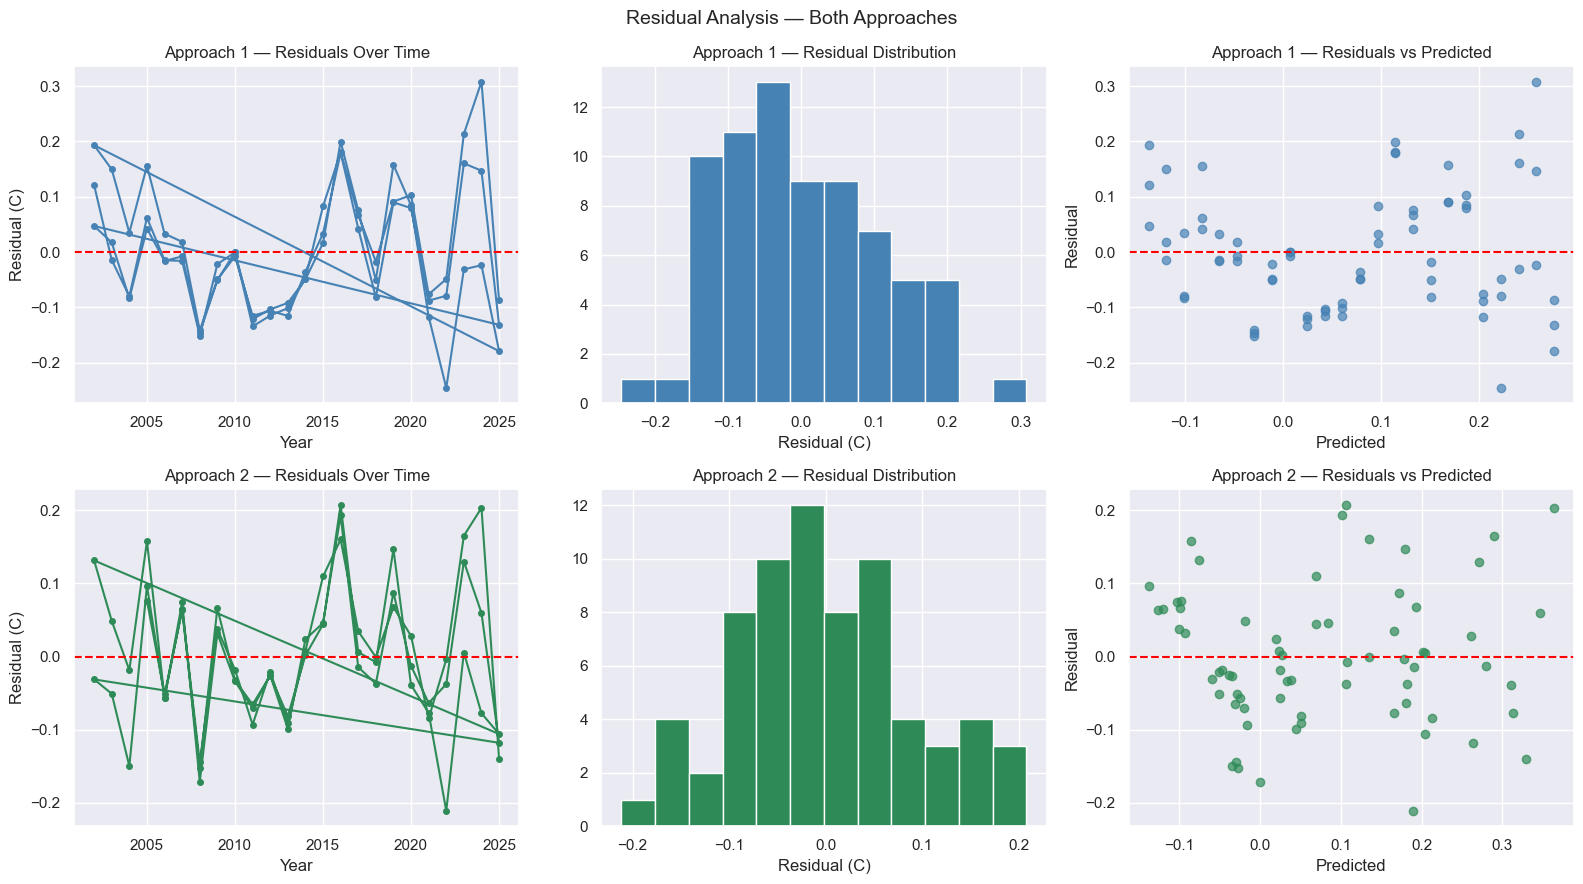

Approach 1 — Mean Residual: 0.000000, Std: 0.108969
Approach 2 — Mean Residual: 0.000000, Std: 0.093435


In [136]:
# Residuals for both approaches
hist_pred_ts_full  = best_ts.predict(X_ts_scaled)
hist_pred_lag_full = best_lag.predict(X_lag_scaled)

residuals_ts  = y_ts - hist_pred_ts_full
residuals_lag = y_lag - hist_pred_lag_full

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# Approach 1 residuals
axes[0,0].plot(df['Year'], residuals_ts, color='steelblue', marker='o', markersize=4)
axes[0,0].axhline(0, color='red', linestyle='--')
axes[0,0].set_title('Approach 1 — Residuals Over Time')
axes[0,0].set_xlabel('Year'); axes[0,0].set_ylabel('Residual (C)')

axes[0,1].hist(residuals_ts, bins=12, color='steelblue', edgecolor='white')
axes[0,1].set_title('Approach 1 — Residual Distribution')
axes[0,1].set_xlabel('Residual (C)')

axes[0,2].scatter(hist_pred_ts_full, residuals_ts, color='steelblue', alpha=0.7)
axes[0,2].axhline(0, color='red', linestyle='--')
axes[0,2].set_title('Approach 1 — Residuals vs Predicted')
axes[0,2].set_xlabel('Predicted'); axes[0,2].set_ylabel('Residual')

# Approach 2 residuals
axes[1,0].plot(df_lag['Year'], residuals_lag, color='seagreen', marker='o', markersize=4)
axes[1,0].axhline(0, color='red', linestyle='--')
axes[1,0].set_title('Approach 2 — Residuals Over Time')
axes[1,0].set_xlabel('Year'); axes[1,0].set_ylabel('Residual (C)')

axes[1,1].hist(residuals_lag, bins=12, color='seagreen', edgecolor='white')
axes[1,1].set_title('Approach 2 — Residual Distribution')
axes[1,1].set_xlabel('Residual (C)')

axes[1,2].scatter(hist_pred_lag_full, residuals_lag, color='seagreen', alpha=0.7)
axes[1,2].axhline(0, color='red', linestyle='--')
axes[1,2].set_title('Approach 2 — Residuals vs Predicted')
axes[1,2].set_xlabel('Predicted'); axes[1,2].set_ylabel('Residual')

plt.suptitle('Residual Analysis — Both Approaches', fontsize=14)
plt.tight_layout(); plt.show()

print(f'Approach 1 — Mean Residual: {residuals_ts.mean():.6f}, Std: {residuals_ts.std():.6f}')
print(f'Approach 2 — Mean Residual: {residuals_lag.mean():.6f}, Std: {residuals_lag.std():.6f}')

---
## Improvement 3: Learning Curves

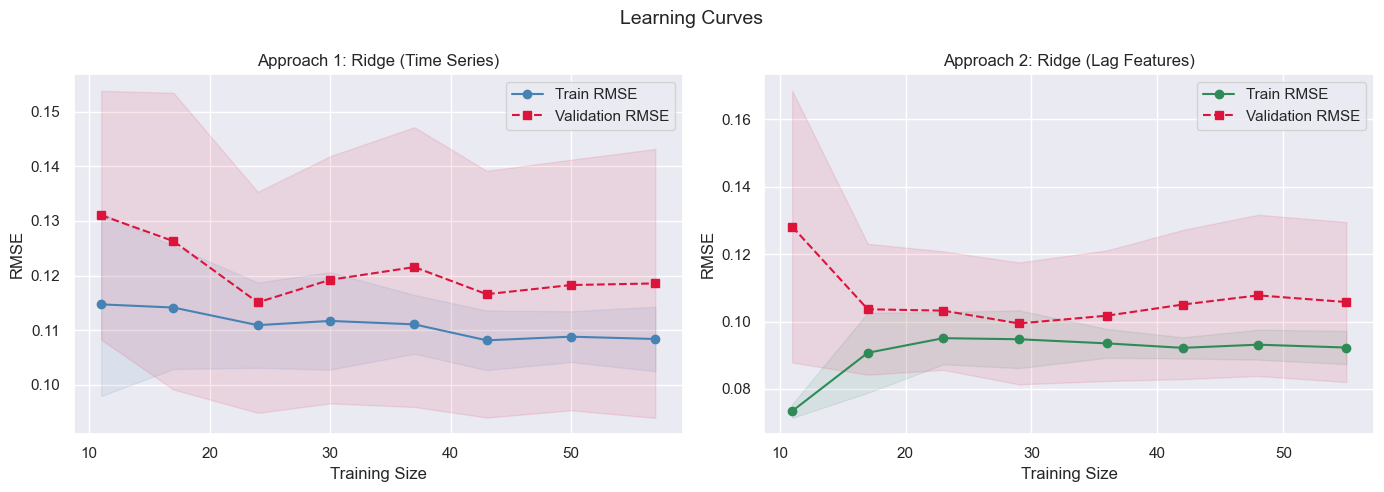

In [137]:
from sklearn.model_selection import learning_curve

def plot_learning_curve(model, X, y, title, ax, color):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y, cv=5, scoring='neg_mean_squared_error',
        train_sizes=np.linspace(0.2, 1.0, 8), shuffle=True, random_state=42
    )
    train_rmse = np.sqrt(-train_scores.mean(axis=1))
    val_rmse   = np.sqrt(-val_scores.mean(axis=1))
    train_std  = np.sqrt(-train_scores).std(axis=1)
    val_std    = np.sqrt(-val_scores).std(axis=1)

    ax.plot(train_sizes, train_rmse, 'o-', color=color, label='Train RMSE')
    ax.plot(train_sizes, val_rmse, 's--', color='crimson', label='Validation RMSE')
    ax.fill_between(train_sizes, train_rmse - train_std, train_rmse + train_std, alpha=0.1, color=color)
    ax.fill_between(train_sizes, val_rmse - val_std, val_rmse + val_std, alpha=0.1, color='crimson')
    ax.set_title(title); ax.set_xlabel('Training Size'); ax.set_ylabel('RMSE')
    ax.legend()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_learning_curve(Ridge(alpha=1.0),        X_ts_scaled,  y_ts,  'Approach 1: Ridge (Time Series)', axes[0], 'steelblue')
plot_learning_curve(Ridge(alpha=1.0),        X_lag_scaled, y_lag, 'Approach 2: Ridge (Lag Features)', axes[1], 'seagreen')
plt.suptitle('Learning Curves', fontsize=14)
plt.tight_layout(); plt.show()

---
## Improvement 4: Feature Importance

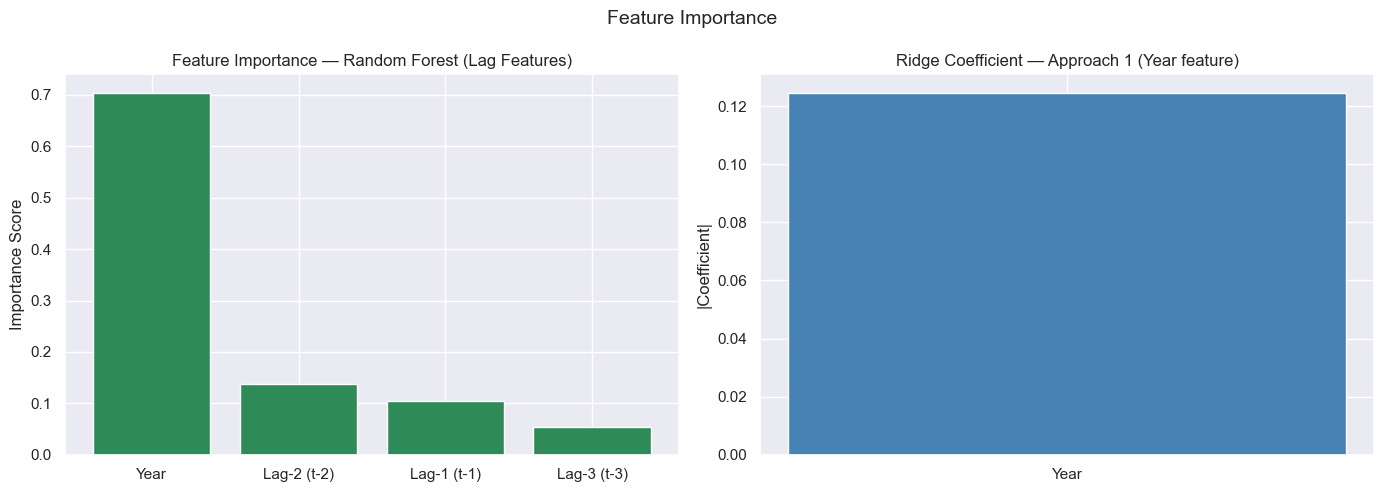

Feature Importances (Approach 2):
  Year: 0.7047
  Lag-2 (t-2): 0.1371
  Lag-1 (t-1): 0.1049
  Lag-3 (t-3): 0.0533


In [138]:
# Feature importance — Random Forest on lag features
rf_importance = RandomForestRegressor(n_estimators=100, random_state=42)
rf_importance.fit(X_lag_scaled, y_lag)

feature_names = ['Year', 'Lag-1 (t-1)', 'Lag-2 (t-2)', 'Lag-3 (t-3)']
importances   = rf_importance.feature_importances_
indices       = np.argsort(importances)[::-1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
axes[0].bar([feature_names[i] for i in indices], importances[indices], color='seagreen', edgecolor='white')
axes[0].set_title('Feature Importance — Random Forest (Lag Features)')
axes[0].set_ylabel('Importance Score')

# Ridge coefficients (Approach 1 — time series)
ridge_coef = Ridge(alpha=1.0)
ridge_coef.fit(X_ts_scaled, y_ts)
axes[1].bar(['Year'], np.abs(ridge_coef.coef_), color='steelblue', edgecolor='white')
axes[1].set_title('Ridge Coefficient — Approach 1 (Year feature)')
axes[1].set_ylabel('|Coefficient|')

plt.suptitle('Feature Importance', fontsize=14)
plt.tight_layout(); plt.show()

print('Feature Importances (Approach 2):')
for i in indices:
    print(f'  {feature_names[i]}: {importances[i]:.4f}')

---
## Improvement 5: Confidence Intervals (Bootstrap)

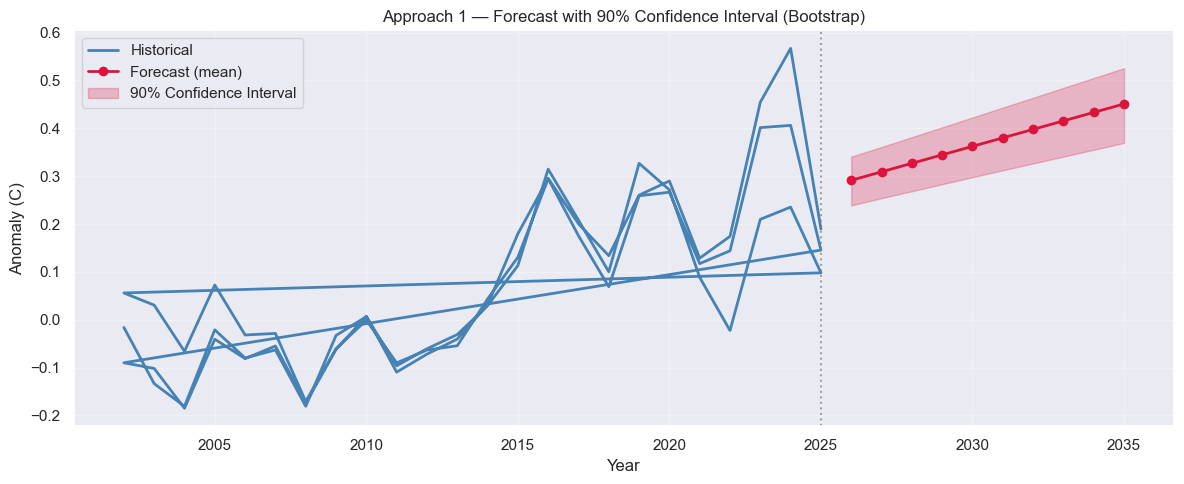

,Year,Forecast,Lower 5%,Upper 95%
0,2026,0.2914,0.2388,0.3408
1,2027,0.3091,0.2541,0.3609
2,2028,0.3268,0.2684,0.3815
3,2029,0.3445,0.2831,0.4021
4,2030,0.3623,0.2978,0.4226
5,2031,0.3800,0.3123,0.4432
6,2032,0.3977,0.3265,0.4638
7,2033,0.4155,0.3408,0.4844
8,2034,0.4332,0.3551,0.5050
9,2035,0.4509,0.3694,0.5256


In [139]:
# Bootstrap confidence intervals for forecast uncertainty
np.random.seed(42)
N_BOOTSTRAP = 200
future_years_arr = np.arange(2026, 2036).reshape(-1, 1)
future_scaled_ci = scaler_ts.transform(future_years_arr)

boot_preds = np.zeros((N_BOOTSTRAP, len(future_years_arr)))
for i in range(N_BOOTSTRAP):
    idx = np.random.choice(len(X_ts_scaled), len(X_ts_scaled), replace=True)
    X_b, y_b = X_ts_scaled[idx], y_ts[idx]
    m = Ridge(alpha=1.0)
    m.fit(X_b, y_b)
    boot_preds[i] = m.predict(future_scaled_ci)

ci_lower = np.percentile(boot_preds, 5,  axis=0)
ci_upper = np.percentile(boot_preds, 95, axis=0)
ci_mean  = boot_preds.mean(axis=0)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df['Year'], y_ts, label='Historical', color='steelblue', linewidth=2)
ax.plot(future_years_arr, ci_mean, label='Forecast (mean)', color='crimson', marker='o', linewidth=2)
ax.fill_between(future_years_arr.flatten(), ci_lower, ci_upper, alpha=0.25, color='crimson', label='90% Confidence Interval')
ax.axvline(2025, color='gray', linestyle=':', alpha=0.7)
ax.set_title('Approach 1 — Forecast with 90% Confidence Interval (Bootstrap)')
ax.set_xlabel('Year'); ax.set_ylabel('Anomaly (C)')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

ci_df = pd.DataFrame({
    'Year'      : future_years_arr.flatten(),
    'Forecast'  : ci_mean.round(4),
    'Lower 5%'  : ci_lower.round(4),
    'Upper 95%' : ci_upper.round(4)
})
display(ci_df)

---
## Improvement 6: Model Saving & Loading (joblib)

In [140]:
import joblib
import os

# Save all models and scalers
joblib.dump(scaler_ts,   'scaler_ts.pkl')
joblib.dump(scaler_lag,  'scaler_lag.pkl')
joblib.dump(best_ts,     'model_approach1.pkl')
joblib.dump(best_lag,    'model_approach2.pkl')
joblib.dump(tuned_ridge, 'model_tuned_ridge.pkl')
joblib.dump(tuned_rf,    'model_tuned_rf.pkl')

saved = ['scaler_ts.pkl','scaler_lag.pkl','model_approach1.pkl','model_approach2.pkl','model_tuned_ridge.pkl','model_tuned_rf.pkl']
print('Saved files:')
for f in saved:
    size = os.path.getsize(f) / 1024
    print(f'  {f} — {size:.1f} KB')

# Verify loading works correctly
loaded_model  = joblib.load('model_approach1.pkl')
loaded_scaler = joblib.load('scaler_ts.pkl')
test_input    = loaded_scaler.transform([[2030]])
test_pred     = loaded_model.predict(test_input)[0]
print(f'\nVerification — Loaded model prediction for 2030: {test_pred:.4f} C')

Saved files:
  scaler_ts.pkl — 0.6 KB
  scaler_lag.pkl — 0.7 KB
  model_approach1.pkl — 0.5 KB
  model_approach2.pkl — 0.6 KB
  model_tuned_ridge.pkl — 0.5 KB
  model_tuned_rf.pkl — 258.0 KB

Verification — Loaded model prediction for 2030: 0.3670 C
